# setup

In [1]:
import sys
from pathlib import Path

# put src/ on the path — this notebook lives in src/analysis_notebooks/
SRC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'params.py').exists())
sys.path.insert(0, str(SRC))
import utils
import params
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

In [2]:
def deleting_itu_func(data,outcome_var,indicator):
    for iso3 in data.iso3.unique():
        if 'itu' in data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].values:
            if data.loc[data['iso3']==iso3,f'{indicator}_survey_type'].nunique()==1:
                #print(iso3,data.loc[data['iso3']==iso3,f'{outcome_var}'].values)
                survey_values = [x if x>0.85 else None for x in data.loc[data['iso3']==iso3,f'{outcome_var}'].values]
                data.loc[data['iso3']==iso3,f'{outcome_var}']= survey_values
                #print(data.loc[data['iso3']==iso3,f'{outcome_var}'].values)
            else:
                data.loc[data['iso3']=='iso3',f'{outcome_var}']=[x if y!='itu' else None for x,y in zip(data.loc[data['iso3']=='iso3',f'{outcome_var}'],data.loc[data['iso3']=='iso3',f'{indicator}_survey_type'])]
    return data 

In [3]:

# Initialize an empty DataFrame to store the results
results_df = pd.DataFrame(columns=['model_name', 'method', 'outcome_var', 'model_type', 'best_adj_r2', 'best_r2', 'loco_r2', 'loyo_r2','loconto_r2','selected_var'])
country_specific_df = pd.DataFrame(columns=["name",'outcome_var','model_type','country','pred','true','train_size'])
year_specific_df = pd.DataFrame(columns=["name", 'outcome_var','model_type','year','pred','true','train_size'])
continent_specific_df = pd.DataFrame(columns=["name",'outcome_var','model_type','conti','pred','true','train_size'])


# dataset = "combined_multiple_years_no_missing_fb_aligned.csv"
dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
def extract_info_from_filename(filename):
    if "no_missing" in filename:
        missing_imputed = True
    else:
        missing_imputed = False

    year = filename.split('_')[-1].split('-')[0]
    return missing_imputed, year


def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    return data


def save_model(model, file_path):
    joblib.dump(model, file_path)


def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None


def evaluate_random_forest_leave_one_out(indicator, dataset, model_type, country_specific_df, year_specific_df, continent_specific_df, outcome_var, deleting_itu=False,with_year=False):
    # Load the dataset
 
        
    data = pd.read_csv(data_path / dataset)
    if deleting_itu:
        data=deleting_itu_func(data,outcome_var,indicator)
           
    model_spec = model_specs[model_type]
    model_spec = [f'year'] + model_spec if with_year else model_spec
    #print(f"model_spec: {model_spec}")
    
    # Drop rows where the target variable is missing
    data = data.dropna(subset=[f'{outcome_var}'])
    data.rename(columns={f'{indicator}_year':'year'}, inplace=True)

    # Preprocess data
    X = preprocess_data(data[model_spec])
    y = data[outcome_var]

    # Check if a model for this specific validation already exists
    model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_","")}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/18_plus{"_no_itu" if deleting_itu else ""}{"_with_year" if with_year else ""}' / model_filename

    # Try to load the model if it exists
    rf_loo = load_model(model_filepath)

    # If no model exists, train a new one
    if rf_loo is None:
        rf_loo = RandomForestRegressor(random_state=42)
        rf_loo.fit(X, y)
        save_model(rf_loo, model_filepath)

    y_pred_full = rf_loo.predict(X)
    r2_full_sample = r2_score(y, y_pred_full)


    # leave one out validation
    def leave_one_column_out(column):
        recorder = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', column, 'pred', 'true', 'train_size'])
        for unique_value in data[column].unique():
            X_train_loo = X[data[column] != unique_value]
            y_train_loo = y[data[column] != unique_value]

            X_test_loo = X[data[column] == unique_value]
            y_test_loo = y[data[column] == unique_value]

            # Check if a model for this specific validation already exists
            model_filename = f'{indicator}_{model_type}_{outcome_var}_{column}_{unique_value}_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_","")}_{outcome_var}_{column}_{unique_value}_model.pkl'
            model_filepath = params.dropbox_data_path.parent /  f'models/18_plus{"_no_itu" if deleting_itu else ""}{"_with_year" if with_year else ""}' / model_filename

            # Try to load the model if it exists
            rf_loo = load_model(model_filepath)

            # If no model exists, train a new one
            if rf_loo is None:
                rf_loo = RandomForestRegressor(random_state=42)
                rf_loo.fit(X_train_loo, y_train_loo)
                save_model(rf_loo, model_filepath)

            y_pred_loo = rf_loo.predict(X_test_loo)
            for i in range(len(y_pred_loo)):
                recorder.loc[len(recorder)] = [f'{indicator} {model_type}', outcome_var, model_type, unique_value, y_pred_loo[i], y_test_loo.values[i], len(y_train_loo)]

        r2 = r2_score(recorder['true'], recorder['pred'])
        return recorder, r2

    r2s = {}
    for leave_column in ['iso3', 'year', 'conti']:
        temp, r2s[leave_column] = leave_one_column_out(leave_column)
        if leave_column == 'iso3':
            country_specific_df = pd.concat([country_specific_df, temp], axis=0)
        elif leave_column == 'year':
            year_specific_df = pd.concat([year_specific_df, temp], axis=0)
        # else:
        #     continent_specific_df = pd.concat([continent_specific_df,temp], axis=0)

    # ----------------------------------------
    # Append the results to the main DataFrame
    results_df.loc[len(results_df)] = {
        "model_name": f'{indicator} {model_type}',
        'method': 'Random Forest',
        'outcome_var': outcome_var,
        "model_type": model_type,
        'best_r2': r2_full_sample,
        'loco_r2': r2s['iso3'],
        'loyo_r2': r2s['year'],
        # 'loconto_r2':r2s['conti'],
        'selected_var': ''
    }

    return year_specific_df, country_specific_df, continent_specific_df, results_df

##  mobile dgg

In [4]:
deleting_itu = True 
with_year = True
for indicator in ['internet','mobile']:
    
    data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
    data = pd.read_csv(data_path / f"combined_multiple_years_no_missing_keep_countries_fb_aligned.csv")
    
    
    '''    print("indicator: ", indicator,data[f'{indicator}_survey_type'].notnull().sum())
        data[f'{indicator}_survey_type'] = data[f'{indicator}_survey_type'].fillna("")
        itu_countries = data[data[f'{indicator}_survey_type'].str.contains("itu")]['iso3'].unique()
        dhs_countries = data[data[f'{indicator}_survey_type'].str.contains("dhs")]['iso3'].unique()
        itu_dhs_countries = set(itu_countries).intersection(set(dhs_countries))
        print (f"itu_dhs_countries: {itu_dhs_countries}")
    '''
    
    
    
    fb_cols =["fb_18_999_men","fb_18_999_wom","fb_18_999_r"]
    bg_cols = params.bg_cols
    model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}
    
    for model_type in ['online', 'offline', 'combined']:
        for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
            year_specific_df, country_specific_df, continent_specific_df, results_df = evaluate_random_forest_leave_one_out(indicator, dataset, model_type, country_specific_df, year_specific_df, continent_specific_df, outcome_var, deleting_itu,with_year)
    """
    country_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest{"_no_ITU" if deleting_itu else ""}{"with_year" if with_year else ""}_loco_results_{indicator}.csv', index=False)
    year_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest{"_no_ITU" if deleting_itu else ""}{"with_year" if with_year else ""}_loyo_results_{indicator}.csv', index=False)
    continent_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest_{"_no_ITU" if deleting_itu else ""}{"with_year" if with_year else ""}_loconto_results_{indicator}.csv', index=False)
    results_df.to_csv(params.dropbox_data_path.parent/f'results/random_forest{"_no_ITU" if deleting_itu else ""}{"with_year" if with_year else ""}_results_summary_{indicator}.csv', index=False)
    """

FileNotFoundError: [Errno 2] No such file or directory: '/Users/valler/Python/RA/Gender_Inequality/dgg_national/data/external/national/data_refresh/new_national_pipeline_files/models/18_plus_no_itu_with_year/internet_online_internet_ggi_full_model.pkl'

In [5]:
results_df.to_csv(params.dropbox_data_path.parent/f'results/random_forest{"_no_ITU" if deleting_itu else ""}{"with_year" if with_year else ""}_results_summary_{indicator}.csv', index=False)

In [6]:
results_df

,model_name,method,outcome_var,model_type,best_adj_r2,best_r2,loco_r2,loyo_r2,loconto_r2,selected_var


In [7]:
# retrerive the results predicted from full model 

def full_model_predictions(indicator, dataset, model_type, outcome_var, deleting_itu=False,with_year=False):
    # Load the dataset
    #print('outcome_var:', outcome_var)
    predicted_results = pd.DataFrame(columns=["iso3","year", 'outcome_var','model_type','pred','true'])
    data = pd.read_csv(data_path / dataset)
    
    if deleting_itu:
       data=deleting_itu_func(data,outcome_var,indicator)
    
    model_spec = model_specs[model_type]
    model_spec = [f'year'] + model_spec if with_year else model_spec
    # print(f"model_spec: {model_spec}")
    # Drop rows where the target variable is missing
    data.rename(columns={f'{indicator}_year':'year'}, inplace=True)
    data = data.dropna(subset=model_spec)
    
     
    # Preprocess data
    X = preprocess_data(data[model_spec])
    y = data[outcome_var]
    
    # Check if a model for this specific validation already exists
    model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_","")}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/18_plus{"_no_itu" if deleting_itu else ""}{"_with_year" if with_year else ""}' / model_filename

    #print(model_filepath)
    # Try to load the model if it exists
    rf_loo = load_model(model_filepath)
    
    y_pred_full = rf_loo.predict(X)
    predicted_results['iso3'] = data['iso3']
    predicted_results["year"] = data[f'year']
    predicted_results['outcome_var'] = outcome_var
    predicted_results['model_type'] = model_type
    predicted_results['pred'] = y_pred_full
    predicted_results['true'] = y
    
    # Check the r2 score
    data_full = pd.read_csv(data_path / dataset)
    #data_full[outcome_var]=data_full[outcome_var].fillna(0)
    predicted_results['all_true'] = [data_full.loc[(data_full['iso3'] == iso3) & (data_full[f'{indicator}_year'] == year), outcome_var].values[0] if (pd.notnull(year)) else None for iso3, year in zip(predicted_results['iso3'], predicted_results['year'])]
    
    temp = predicted_results[predicted_results['all_true'].notnull()]
    print(f" {model_type}  {outcome_var} r2: {r2_score(temp['all_true'], temp['pred'])}")
    return predicted_results
    


In [8]:
fb_cols =["fb_18_999_men","fb_18_999_wom","fb_18_999_r"]
bg_cols = params.bg_cols
model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}
predicted_results = pd.DataFrame(columns=["iso3", "year", 'outcome_var','model_type','pred','true'])

for indicator in ['mobile','internet']:
    for year in range(2015,2026):
        print(year)
        data_path = params.dropbox_data_path / f"combined_data/updated_ground_truth_and_fb/{indicator}"
        dataset = f"year_align/combined_multiple_years_no_missing_fb_aligned_{year}.csv"
        for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
            temp = full_model_predictions(indicator, dataset, model_type,outcome_var, deleting_itu,with_year)
            temp['align_year']=year                             
            predicted_results = pd.concat([predicted_results,temp], axis=0)



if deleting_itu:
    predicted_results['itu'] = [False if (pd.notnull(x) and pd.notnull(y)) else True for x,y in zip(predicted_results['true'], predicted_results['all_true'])]
    predicted_results['itu'] = predicted_results['itu'].astype(int)
else:
    predicted_results['itu'] = [True if data.loc[(data['iso3']==iso3) & (data[f'{indicator}_year']==year),
    f'{indicator}_survey_type'].values[0]=='itu' else False for iso3,year in zip(predicted_results['iso3'],predicted_results['year'])]
    predicted_results['itu'] = predicted_results['itu'].astype(int)

2015


AttributeError: 'NoneType' object has no attribute 'predict'

KeyError: 'itu'

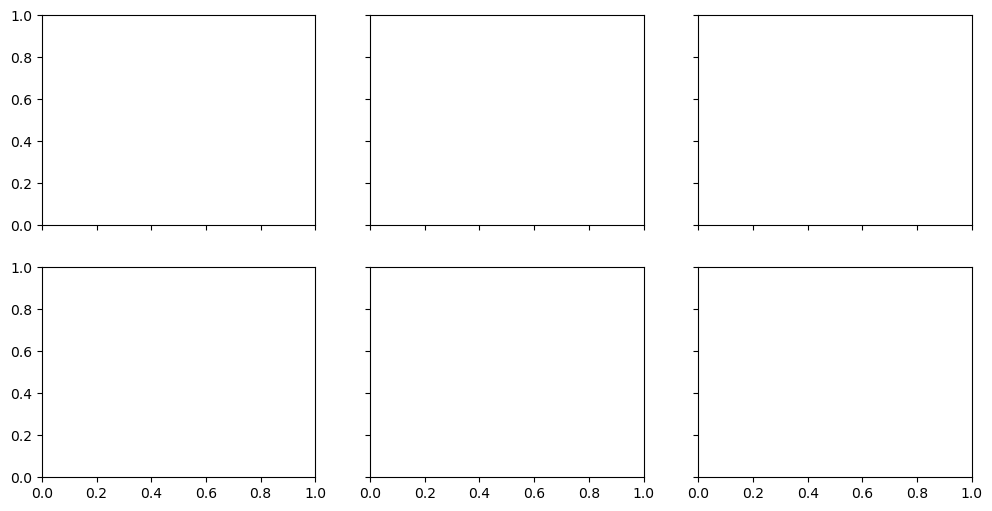

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)  # Two rows, three columns

# Get unique years in ascending order (excluding NaNs first)
unique_years = sorted(predicted_results['year'].dropna().unique())  # Exclude NaNs
unique_years = [str(round(x)) for x in unique_years]  # Convert to strings
# Define color mapping: bluer as year increases, 'No-Year' as red
color_palette = sns.color_palette("Blues", len(unique_years))  
year_cmap = {year: color_palette[i] for i, year in enumerate(unique_years)}

# Loop through outcomes and ITU conditions
for row, itu_val in enumerate([0, 1]):  # First row: ITU==0, Second row: ITU==1
    for col, outcome_var in enumerate([f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']):
        ax = axes[row, col]
        temp = predicted_results[
            (predicted_results['outcome_var'] == outcome_var) & 
            (predicted_results['model_type'] == 'combined') &
            (predicted_results['itu'] == itu_val) &

            (pd.notnull(predicted_results['year']))
        ]

        temp['year'] = [str(round(x)) if pd.notnull(x) else 'No-Year' for x in temp['year']]
        
        # Scatter plot with consistent color mapping
        sns.scatterplot(data=temp, x='all_true', y='pred', hue='year', palette=year_cmap, alpha=1, ax=ax, legend=False)

        # Diagonal reference line
        ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c="red", alpha=0.8)  

        # Titles
        if row == 0:
            ax.set_title(f"{outcome_var.replace('_', ' ')} prediction")

        ax.set_xlabel('Ground Truth')
        ax.set_ylabel('Predicted - ITU' if itu_val == 1 else 'Predicted - Non-ITU')
        ax.grid(True,alpha=0)
        # Annotation of data length in the bottom-right corner
        ax.text(0.95, 0.05, f"N={len(temp)} \n R2 = {round(r2_score(temp['all_true'],temp['pred']),3)}", transform=ax.transAxes, 
                fontsize=10, verticalalignment='bottom', horizontalalignment='right', 
                bbox=dict(facecolor='white', alpha=0, boxstyle="round,pad=0.1"))
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
# Create a single legend at the bottom
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=year_cmap[year], markersize=8) for year in unique_years]
plt.legend(handles, unique_years, title="Year", loc='upper center', bbox_to_anchor=(-0.9, -0.2), ncol=10,frameon=False) 
fig.subplots_adjust(bottom=0.2)

# plt.savefig(params.dropbox_data_path.parent / f'graphs/result_check/combined_model_no_ITU_{indicator}{"_no_itu" if deleting_itu else ""}.pdf')

In [10]:
predicted_results.loc[(predicted_results['itu']==1) & (predicted_results['all_true']>predicted_results['pred'])&(predicted_results['model_type']=='combined'),'all_true'].describe()

KeyError: 'itu'

In [11]:
df_subnational_all = pd.read_csv(params.dropbox_data_path.parent/"files/subnational_aggregated_to_national.csv")
df_subnational_all

,gid_0,outcome,year,predicted_subnational
0,AFG,internet_fm_ratio,2015,0.221003
1,AFG,internet_fm_ratio,2016,0.223953
2,AFG,internet_fm_ratio,2017,0.234766
3,AFG,internet_fm_ratio,2018,0.247401
4,AFG,internet_fm_ratio,2019,0.255636
...,...,...,...,...
7723,ZWE,mobile_women,2021,0.698046
7724,ZWE,mobile_women,2022,0.575954
7725,ZWE,mobile_women,2023,0.590253
7726,ZWE,mobile_women,2024,0.684110


In [12]:
predicted_results.loc[predicted_results]

ValueError: Cannot index with multidimensional key

In [13]:
predicted_results['outcome_var']=predicted_results['outcome_var'].replace({'mobile_ggi':'mobile_fm_ratio','mobile_wom':'mobile_women',"internet_ggi":'internet_fm_ratio',"internet_wom":'internet_women'})
predicted_results_all= predicted_results.merge(df_subnational_all,left_on=['iso3','outcome_var','align_year'],right_on=['gid_0','outcome','year'],how='left')


KeyError: 'align_year'

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score,mean_absolute_error
# Assume df is your DataFrame containing national and subnational predictions
# df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Get unique years
df = predicted_results_all.copy()
years = sorted(df['align_year'].unique())

# Define unique outcome types
outcome_types = [x for x in df['outcome'].unique() if pd.notnull(x)]

# Create subplots for each outcome type
for outcome in outcome_types:
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(4 * 4, 3*3), sharey=True)
    axes=axes.flatten()
    for i, year in enumerate(years):
        ax = axes[i] if len(years) > 1 else axes  # Handle single subplot case
        df_filtered = df[(df['outcome'] == outcome) & (df['align_year'] == year)]

        # Scatter plot comparing National vs. Subnational predictions
        sns.scatterplot(data=df_filtered, x="pred", y="predicted_subnational", ax=ax,legend=False)

        ax.set_title(f"Year: {year}")
        ax.set_xlabel("National Prediction")
        ax.set_ylabel("Subnational Prediction" if i == 0 else "")  # Only label the first subplot for clarity
        ax.set_xlim([0,1.2])
        ax.set_ylim([0,1.2])

        # Add diagonal reference line (y=x) for easy comparison
        min_val = min(df['pred'].min(), df['predicted_subnational'].min()) * 0.9
        max_val = max(df['pred'].max(), df['predicted_subnational'].max()) * 1.1
        ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", alpha=0.7)
        r2= r2_score(df_filtered['pred'],df_filtered['predicted_subnational'])
        mae = mean_absolute_error(df_filtered['pred'],df_filtered['predicted_subnational'])
        ax.text(0.95, 0.05, f"mae={round(mae,3)} \n R2 = {round(r2,3)}", transform=ax.transAxes, 
                fontsize=10, verticalalignment='bottom', horizontalalignment='right', 
                bbox=dict(facecolor='white', alpha=0, boxstyle="round,pad=0.1"))
        
    plt.suptitle(f"Comparison of National vs. Subnational Predictions ({outcome})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

NameError: name 'predicted_results_all' is not defined

In [15]:
outcome_types

NameError: name 'outcome_types' is not defined

In [16]:
predicted_results_all['diff'] = predicted_results_all['pred']-predicted_results_all['predicted_subnational']

NameError: name 'predicted_results_all' is not defined

In [17]:
predicted_results_all['diff'].describe()

NameError: name 'predicted_results_all' is not defined

In [18]:
temp = predicted_results_all.loc[(predicted_results_all['predicted_subnational'].notnull()) & (predicted_results_all['all_true'].notnull())&(predicted_results_all['itu']==0),]
print(r2_score(temp['predicted_subnational'],temp['all_true']),)

NameError: name 'predicted_results_all' is not defined

In [19]:
temp = predicted_results_all.loc[(predicted_results_all['pred'].notnull()) & (predicted_results_all['all_true'].notnull())&(predicted_results_all['itu']==0),]
r2_score(temp['pred'],temp['all_true'])

NameError: name 'predicted_results_all' is not defined

In [20]:
}import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume predicted_results_all is your DataFrame

# Define unique outcome types
outcome_types = [x for x in predicted_results_all['outcome'].unique() if pd.notnull(x)]

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12), sharex=True)

# If there's only one outcome type, `axes` is not an array, so we ensure it's iterable
if len(outcome_types) == 1:
    axes = [axes]

axes = axes.flatten()
# Plot each outcome in its own subplot
for ax, outcome in zip(axes, outcome_types):
    df_filtered = predicted_results_all[predicted_results_all['outcome'] == outcome]
    
    # Plot national predictions
    sns.lineplot(data=df_filtered, x="align_year", y="pred", label="National Prediction",
                 marker="o", linestyle="-", linewidth=2, ax=ax, color="blue")
    
    # Plot subnational predictions
    sns.lineplot(data=df_filtered, x="align_year", y="predicted_subnational", label="Subnational Aggregated Prediction",
                 marker="s", linestyle="--", linewidth=2, ax=ax, color="red")

    ax.set_title(f"Comparison of National vs. Subnational Predictions ({outcome})")
    ax.set_ylabel("Prediction Value")
    ax.legend(title="Prediction Type")
    ax.grid(True)

# Set common labels
axes[-1].set_xlabel("Year")  # Only set xlabel for the last subplot to avoid redundancy

plt.tight_layout()
plt.show()

SyntaxError: unmatched '}' (4210670340.py, line 1)

#import pycountry  as pyc

#[pyc.countries.get(alpha_3=x).name for x in predicted_results.loc[(predicted_results['itu']==1) & (predicted_results['all_true']>predicted_results['pred'])&(predicted_results['model_type']=='combined'),'iso3'].unique()]
countries = predicted_results.loc[(predicted_results['itu']==1) & (predicted_results['all_true']>predicted_results['pred'])&(predicted_results['model_type']=='combined'),'iso3'].unique()
predicted_results.loc[predicted_results.]

## compare with our last prediction

In [21]:
# retrerive the results predicted from full model 

def full_model_predictions(indicator, dataset, model_type, outcome_var, deleting_itu=False):
    # Load the dataset
    #print('outcome_var:', outcome_var)
    predicted_results = pd.DataFrame(columns=["iso3","year", 'outcome_var','model_type','pred','true'])
    data = pd.read_csv(data_path / dataset)
    
    if deleting_itu:
       data[f'{outcome_var}'] = [None if "itu" in str(y) else x for x, y in zip(data[f'{outcome_var}'], data[f'{indicator}_survey_type'])]
    
    model_spec = model_specs[model_type]
    # print(f"model_spec: {model_spec}")
    # Drop rows where the target variable is missing
    data = data.dropna(subset=model_spec)
    data.rename(columns={f'{indicator}_year':'year'}, inplace=True)
     
    # Preprocess data
    
    y = data[outcome_var]
    
    # Check if a model for this specific validation already exists
    model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl' if deleting_itu else f'{indicator}_{model_type}_{outcome_var.replace(f"{indicator}_","")}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/18_plus{"_no_itu" if deleting_itu else ""}' / model_filename

    # Try to load the model if it exists
    rf_loo = load_model(model_filepath)
    
    X = preprocess_data(data[rf_loo.feature_names_in_])
    y_pred_full = rf_loo.predict(X)
    predicted_results['iso3'] = data['iso3']
    predicted_results["year"] = data[f'year']
    predicted_results['outcome_var'] = outcome_var
    predicted_results['model_type'] = model_type
    predicted_results['pred'] = y_pred_full
    predicted_results['true'] = y
    
    # Check the r2 score
    data_full = pd.read_csv(data_path / dataset)
    #data_full[outcome_var]=data_full[outcome_var].fillna(0)
    predicted_results['all_true'] = [data_full.loc[(data_full['iso3'] == iso3) & (data_full[f'{indicator}_year'] == year), outcome_var].values[0] if (pd.notnull(year)) else None for iso3, year in zip(predicted_results['iso3'], predicted_results['year'])]
    
    temp = predicted_results[predicted_results['all_true'].notnull()]
    print(f" {model_type}  {outcome_var} r2: {r2_score(temp['a dll_true'], temp['pred'])}")
    return predicted_results
    


In [22]:
fb_cols =["fb_18_999_men","fb_18_999_wom","fb_18_999_r"]
bg_cols = params.bg_cols
model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}
predicted_results_last = pd.DataFrame(columns=["iso3","year", 'outcome_var','model_type','pred','true'])
for model_type in ['combined']:
    for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
        predicted_results_last = pd.concat([predicted_results_last,full_model_predictions(indicator, dataset, model_type,outcome_var, deleting_itu=False)], axis=0)


KeyError: 'a dll_true'

predicted_results_last = pd.DataFrame()
for file in os.listdir(params.dropbox_data_path.parent / f'results/pred_by_year_data/18_plus/combined/'):
    if file.endswith(".csv"):
        predicted_results_last = pd.concat([predicted_results_last, pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/18_plus/combined/{file}')], axis=0)
        predicted_results_last= predicted_results_last.loc[(predicted_results_last['indicator']==indicator)]
        

In [23]:
predicted_results_last['outcome_var']=predicted_results_last['outcome_var'].str.replace(f'{indicator}_','')
predicted_results = predicted_results[predicted_results['model_type']=='combined']
predicted_results['outcome_var']=predicted_results['outcome_var'].str.replace(f'{indicator}_','')


predicted_results = predicted_results[predicted_results['model_type']=='combined']
predicted_results_last = predicted_results_last[predicted_results_last['model_type']=='combined']
predicted_results_all=pd.merge(predicted_results,predicted_results_last[['iso3','year','outcome_var','pred']], on=['iso3','year','outcome_var'], how='left', suffixes=('_no_itu','_last' ))

In [24]:
predicted_results_all

,iso3,year,outcome_var,model_type,pred_no_itu,true,pred_last


KeyError: 'itu'

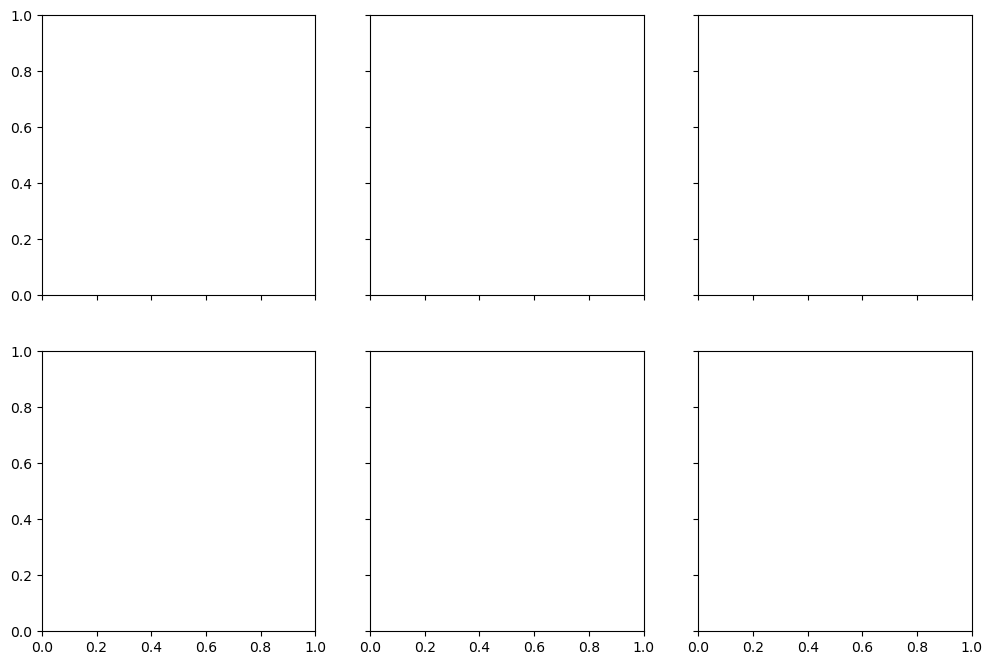

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)  # Two rows, three columns

# Get unique years in ascending order (excluding NaNs first)
unique_years = sorted(predicted_results_all['year'].dropna().unique())  # Exclude NaNs
unique_years = [str(round(x)) for x in unique_years]  # Convert to strings
# Define color mapping: bluer as year increases, 'No-Year' as red
color_palette = sns.color_palette("Blues", len(unique_years))  
year_cmap = {year: color_palette[i] for i, year in enumerate(unique_years)}

# Loop through outcomes and ITU conditions
for row, itu_val in enumerate([0, 1]):  # First row: ITU==0, Second row: ITU==1
    for col, outcome_var in enumerate([f'ggi', f'wom', f'men']):
        ax = axes[row, col]
        temp = predicted_results_all[
            (predicted_results_all['outcome_var'] == outcome_var) & 
            (predicted_results_all['model_type'] == 'combined') &
            (predicted_results_all['itu'] == itu_val) &

            (pd.notnull(predicted_results_all['year']))
        ]

        temp['year'] = [str(round(x)) if pd.notnull(x) else 'No-Year' for x in temp['year']]
        
        # Scatter plot with consistent color mapping
        sns.scatterplot(data=temp, x='pred_last', y='pred_no_itu', hue='year', palette=year_cmap, alpha=1, ax=ax, legend=False)

        # Diagonal reference line
        ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c="red", alpha=0.8)  

        # Titles
        if row == 0:
            ax.set_title(f"{indicator} {outcome_var.replace('_', ' ')} prediction")

        ax.set_xlabel('Last Prediction')
        ax.set_ylabel('No ITU fitted Predicted - ITU data' if itu_val == 1 else 'Predicted - Non-ITU data')

        # Annotation of data length in the bottom-right corner
        ax.text(0.95, 0.05, f"N={len(temp)} \n R2 = {round(r2_score(temp['pred_last'],temp['pred_no_itu']),3)}", transform=ax.transAxes, 
                fontsize=10, verticalalignment='bottom', horizontalalignment='right', 
                bbox=dict(facecolor='white', alpha=0, boxstyle="round,pad=0.1"))
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
# Create a single legend at the bottom
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=year_cmap[year], markersize=8) for year in unique_years]
fig.legend(handles, unique_years, title="Year", loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=10)

plt.tight_layout()
#plt.savefig(params.dropbox_data_path.parent / f'graphs/result_check/combined_model_no_ITU_{indicator}.pdf')

# survey difference 

In [26]:
import pandas as pd 
from pathlib import Path 
df_outcomes = pd.read_csv(Path(params.RAW / "new_groundtruth_national_data.csv"))
df_outcomes = df_outcomes.loc[df_outcomes['survey_year']>=2015]

df_outcomes=df_outcomes.pivot_table(index=['gid_0','source','survey_year'],columns="outcome",values='observed').reset_index()


In [27]:
df_outcomes['internet_available'] = [1 if pd.notnull(x) else 0 for x in df_outcomes['internet_men']]
df_outcomes['mobile_available'] = [1 if pd.notnull(x) else 0 for x in df_outcomes['mobile_men']]
df_outcomes['source_agg'] = ['itu' if x=='itu' else 'dhs' if 'dhs' in x else 'mics' if 'mics' in x else 'other' for x in df_outcomes['source']]

In [28]:
df_outcomes['source_agg'].value_counts()

source_agg
itu     146
dhs      42
mics     31
Name: count, dtype: int64

In [29]:
df_outcomes[['mobile_available','source_agg']].value_counts().reset_index().sort_values(by='mobile_available')

,mobile_available,source_agg,count
1,0,itu,57
0,1,itu,89
2,1,dhs,42
3,1,mics,31


In [30]:

df_outcomes.loc[df_outcomes['mobile_available']==1,['source_agg','survey_year']].value_counts().reset_index().sort_values(by='survey_year',ascending=False)

,source_agg,survey_year,count
0,itu,2022,32
15,dhs,2022,4
20,mics,2022,1
3,itu,2021,10
17,mics,2021,4
16,dhs,2021,4
11,itu,2020,6
19,mics,2020,2
7,dhs,2019,8
2,mics,2019,11


In [31]:
df_outcomes.loc[df_outcomes['internet_available']==1,['source','survey_year']].value_counts().reset_index().sort_values(by='survey_year',ascending=False)

,source,survey_year,count
0,itu,2022,65
13,dhs8,2022,4
24,mics6,2022,1
14,dhs8,2021,4
1,itu,2021,21
16,mics6,2021,4
6,itu,2020,9
17,mics6,2020,2
23,continuous dhs8,2019,1
18,dhs8,2019,2
